# Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("data/nearest-earth-objects(1910-2024).csv")

# Preview Dataset
display(df.head())

# Dataset Size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


Rows: 338199
Columns: 9


# Dataset Overview

In [2]:
# Column Names
print(df.columns.tolist())

# Dataset Information
df.info()

# Statistical Summary
display(df.describe())

['neo_id', 'name', 'absolute_magnitude', 'estimated_diameter_min', 'estimated_diameter_max', 'orbiting_body', 'relative_velocity', 'miss_distance', 'is_hazardous']
<class 'pandas.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  str    
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  str    
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), str(2)
memory usage: 21.0 MB


,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


# Data Cleaning

In [3]:
# Missing Values
print(df.isnull().sum())

# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()

print("Dataset Shape After Cleaning:", df.shape)

neo_id                     0
name                       0
absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
orbiting_body              0
relative_velocity          0
miss_distance              0
is_hazardous               0
dtype: int64
Duplicate Rows: 0
Dataset Shape After Cleaning: (338199, 9)


# Exploratory Data Analysis

is_hazardous
False    295037
True      43162
Name: count, dtype: int64

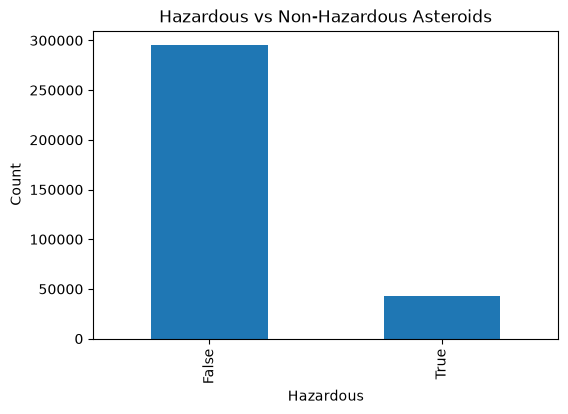

In [4]:
# Number of Hazardous vs Non-Hazardous Asteroids
hazard_counts = df["is_hazardous"].value_counts()

display(hazard_counts)

# Bar Chart
plt.figure(figsize=(6,4))

hazard_counts.plot(kind="bar")

plt.title("Hazardous vs Non-Hazardous Asteroids")
plt.xlabel("Hazardous")
plt.ylabel("Count")

plt.show()

# Diameter Analysis

,estimated_diameter_min,estimated_diameter_max
count,338171.000000,338171.000000
mean,0.157812,0.352878
std,0.313885,0.701869
min,0.000511,0.001143
25%,0.025384,0.056760
50%,0.073207,0.163697
75%,0.189041,0.422708
max,37.545248,83.953727


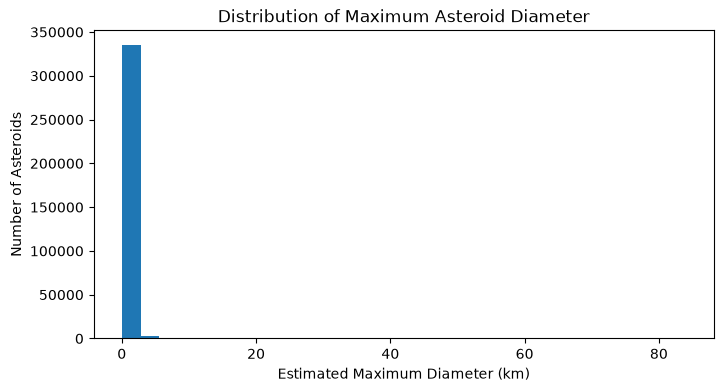

In [5]:
# Diameter Statistics
display(df[["estimated_diameter_min", "estimated_diameter_max"]].describe())

# Distribution of Maximum Diameter
plt.figure(figsize=(8,4))

plt.hist(df["estimated_diameter_max"], bins=30)

plt.title("Distribution of Maximum Asteroid Diameter")
plt.xlabel("Estimated Maximum Diameter (km)")
plt.ylabel("Number of Asteroids")

plt.show()

# Velocity & Miss Distance Analysis

,relative_velocity,miss_distance
count,338199.000000,3.381990e+05
mean,51060.662908,4.153535e+07
std,26399.238435,2.077399e+07
min,203.346433,6.745533e+03
25%,30712.031471,2.494540e+07
50%,47560.465474,4.332674e+07
75%,66673.820614,5.933961e+07
max,291781.106613,7.479865e+07


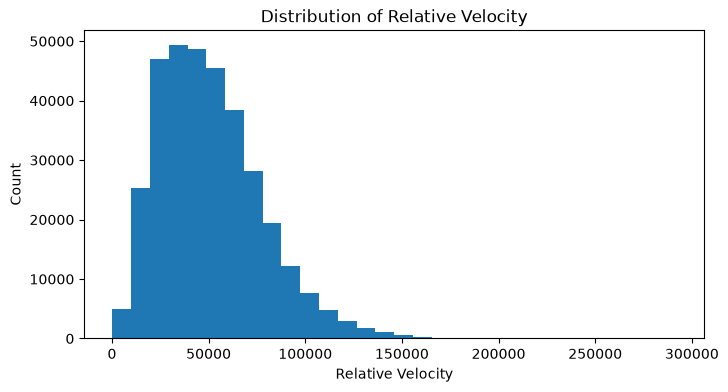

In [7]:
# Summary Statistics
display(df[["relative_velocity", "miss_distance"]].describe())

# Relative Velocity Distribution
plt.figure(figsize=(8,4))

plt.hist(df["relative_velocity"], bins=30)

plt.title("Distribution of Relative Velocity")
plt.xlabel("Relative Velocity")
plt.ylabel("Count")

plt.show()

# Hazard Analysis

In [8]:
# Average values grouped by hazard status
hazard_analysis = df.groupby("is_hazardous")[
    ["estimated_diameter_max", "relative_velocity", "miss_distance"]
].mean()

display(hazard_analysis)

,estimated_diameter_max,relative_velocity,miss_distance
is_hazardous,,,
False,0.308624,49172.265510,4.158731e+07
True,0.655353,63968.941094,4.118015e+07


# Correlation Analysis

In [14]:
# Create a copy for correlation analysis
corr_df = df.copy()

# Convert boolean column to integer
corr_df["is_hazardous"] = corr_df["is_hazardous"].astype(int)

# Select numeric columns
correlation = corr_df.select_dtypes(include="number").corr()

display(correlation)

# Correlation with Hazard Status
display(correlation["is_hazardous"].sort_values(ascending=False))

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,is_hazardous
neo_id,1.000000,0.350145,-0.198471,-0.198471,-0.103078,-0.090735,-0.156748
absolute_magnitude,0.350145,1.000000,-0.594646,-0.594646,-0.345570,-0.213523,-0.343996
estimated_diameter_min,-0.198471,-0.594646,1.000000,1.000000,0.222434,0.111475,0.164841
estimated_diameter_max,-0.198471,-0.594646,1.000000,1.000000,0.222434,0.111475,0.164841
relative_velocity,-0.103078,-0.345570,0.222434,0.222434,1.000000,0.322587,0.187021
miss_distance,-0.090735,-0.213523,0.111475,0.111475,0.322587,1.000000,-0.006540
is_hazardous,-0.156748,-0.343996,0.164841,0.164841,0.187021,-0.006540,1.000000


is_hazardous              1.000000
relative_velocity         0.187021
estimated_diameter_min    0.164841
estimated_diameter_max    0.164841
miss_distance            -0.006540
neo_id                   -0.156748
absolute_magnitude       -0.343996
Name: is_hazardous, dtype: float64

# Asteroid Size vs Hazard Status

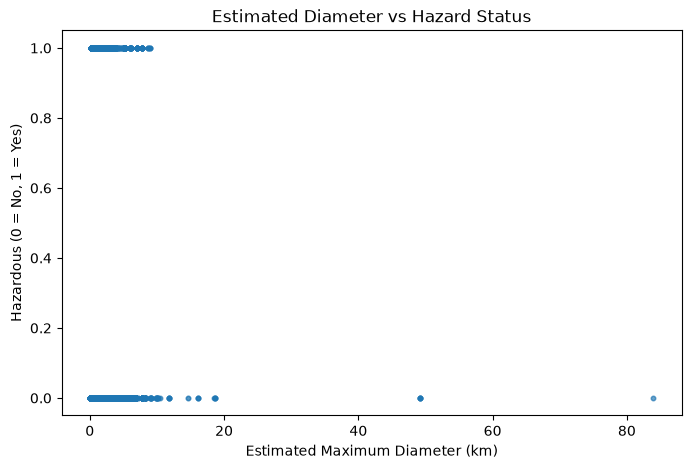

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    corr_df["estimated_diameter_max"],
    corr_df["is_hazardous"],
    alpha=0.3,
    s=10
)

plt.title("Estimated Diameter vs Hazard Status")
plt.xlabel("Estimated Maximum Diameter (km)")
plt.ylabel("Hazardous (0 = No, 1 = Yes)")

plt.show()

# Relative Velocity vs Hazard Status

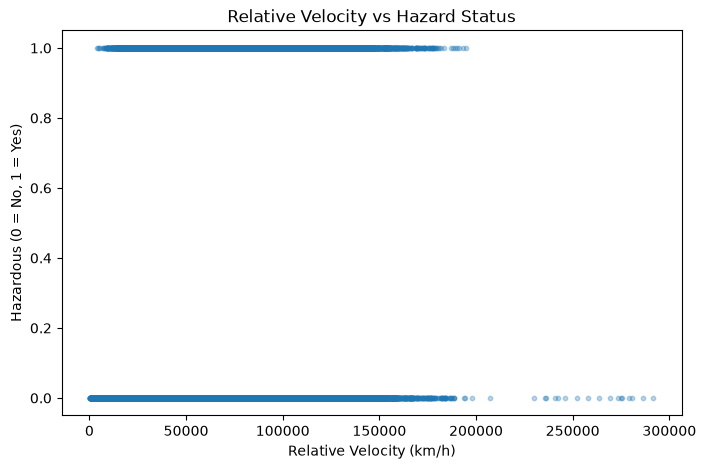

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    corr_df["relative_velocity"],
    corr_df["is_hazardous"],
    alpha=0.3,
    s=10
)

plt.title("Relative Velocity vs Hazard Status")
plt.xlabel("Relative Velocity (km/h)")
plt.ylabel("Hazardous (0 = No, 1 = Yes)")

plt.show()